# 03 — Neural Equivalent Magnetic Circuit

**Project:** NeuRelux. Compares five ways to predict flux density from current, air gap, and temperature: ATLAS's assumed linear circuit, a black-box MLP, a physics-informed model (same free MLP, plus an Ampere's-law residual loss), a physics-constrained model (a free MLP with a hard, known saturation bound), and a physics-encoded neural circuit that only replaces the uncertain permeability term inside the exact circuit equation.

## 1. Motivation

ATLAS's assumed model uses a linear or piecewise-linear reluctance circuit — a reasonable approximation near the calibration point, but one that cannot represent saturation, and has no principled way to extrapolate to unseen current, air gap, or temperature. Notebook 03's original question was narrower: does replacing *only* the uncertain material term (not the whole circuit) beat both the original linear model and a full black-box replacement? This revision widens it to the full guided/informed/constrained/encoded spectrum on the same problem, so the difference between a *soft* physics penalty, a *hard* but partial physical bound, and a *fully* physics-encoded equation is visible on one comparison instead of scattered across notebooks.

## 2. Physical problem

A coil of $N$ turns carrying current $I$ drives magnetic flux through a series magnetic circuit: the core (steel, permeability $\mu_r(B,T)$, saturating as $B$ grows) and an air gap $g$ (constant permeability $\mu_0$, by definition — air doesn't saturate). The air-gap reluctance is *exact geometry*; the core's reluctance is the only genuinely uncertain quantity.

## 3. Governing equations

$$
\Theta = N I, \qquad \Theta = H_{\text{core}}(B,T)\, l_{\text{core}} + \frac{B}{\mu_0} g, \qquad H_{\text{core}}(B,T) = \frac{B}{\mu_0\,\mu_r(B,T)}
$$

This notebook's synthetic "true" system uses a Froehlich-style saturating permeability (illustrative, steel-range parameters — not measured ATLAS data):

$$
\mu_r(B,T) = \frac{\mu_{r0}(T)}{1 + \left(B/B_{\text{sat}}(T)\right)^n}
$$

Given $(\Theta, g, T)$, $B$ is the root of $\Theta - H_{\text{core}}(B,T)\,l_{\text{core}} - (B/\mu_0)g = 0$. The linear and neural-circuit models solve this by fixed-point (successive-substitution) iteration, not a black-box root finder: substitute the current $B$ estimate's permeability into the linear form and repeat (`src/atlas_physics/magnetic_circuit.py::solve_B`), the same fixed-iteration-count philosophy as Notebook 01's explicit Euler and Notebook 02's explicit-stepped Jiles-Atherton. The physics-informed and physics-constrained models below do **not** call `solve_B` at all — they predict $B$ directly, which is exactly what makes them different from the encoded pair.

## 4. What is learned vs. what stays physical

Five models, deliberately spanning the full taxonomy on one problem:

- **Model 1 (linear, PHYSICS-ENCODED but too simple):** a single learned scalar $\mu_r$ (positivity-constrained via softplus), routed through the exact circuit equation via `solve_B`. This *is* physics-encoded — the equation is exact — but the learned quantity is too simple to represent saturation. This is what ATLAS's assumed model does.
- **Model 2 (black-box MLP, PHYSICS-GUIDED at most):** raw $(I,g,T)$ in, $B$ out, no circuit structure anywhere.
- **Model 3 (`PhysicsInformedB`, PHYSICS-INFORMED):** the *same* free-MLP architecture as Model 2, trained on data **plus** a soft Ampere's-law residual loss (`PhysicsInformedB.residual`) evaluated at collocation points inside the training range, using a second, unconstrained permeability network only to compute that residual. Nothing in the forward pass stops it from disagreeing with Ampere's law anywhere the residual wasn't evaluated.
- **Model 4 (`PhysicsConstrainedB`, PHYSICS-CONSTRAINED):** another free MLP, no circuit equation anywhere — but its output is passed through `B_cap * tanh(...)`, a hard bound at a *known* material saturation cap. It cannot structurally predict a flux density beyond what the core can support, in or out of distribution, even though nothing else about its $(I,g,T)$ dependence is constrained.
- **Model 5 (neural circuit, PHYSICS-ENCODED):** keeps the exact same circuit equation and the always-exact air-gap term, but replaces $\mu_r(B,T)$ with `mu_r0 * (1 + 0.3 * tanh(NN(B,T)))` — a small network *bounded to a ±30% multiplicative modulation* of a learned base permeability, not an unconstrained function.

## 5. Dataset description

Fully synthetic, generated directly from the closed-form saturating permeability above — parameters (core length 0.2 m, saturation ~1.6 T, relative permeability ~2000) are illustrative and steel-range, not measured. Data is generated by sampling $B$ directly (avoiding any need to invert the relationship for data generation) and computing the corresponding $\Theta$, then converting to $(I, g, T) \to B$ regression pairs — the natural causal/measurement direction (set current, measure flux).

## 6. Data preprocessing

Inputs normalized by their training-range scales before being fed to any neural network (`I_scale`, `g_scale`, a fixed `T_scale=100`), for the same conditioning reasons as Notebooks 01–02 — though this problem's raw SI magnitudes are far less extreme than those notebooks', so the normalization matters less here than the *extrapolation splits* below.

## 7. Network architecture

`src/atlas_physics/magnetic_circuit.py`: `FixedMuR` (linear), a plain `nn.Sequential` MLP (black-box), `PhysicsInformedB` (free MLP + residual-only permeability net), `PhysicsConstrainedB` (free MLP + hard `tanh` cap), and `NeuralMuR` (physics-encoded, bounded modulation) — the first, fourth and fifth wrapped by the same `solve_B` fixed-point solver; the second and third predict $B$ directly.

## 8. Training

Trained on a *moderate* operating range (sub-saturation current, mid-range gap, moderate temperature) and evaluated on three separate **extrapolation** holdouts — unseen higher current (deeper saturation), unseen air gap, unseen temperature — rather than a random split, since extrapolation is the actual question this notebook asks. The physics-informed model's collocation points are sampled from the *same* training ranges as its data loss, deliberately — the point, as in Notebook 05's PINN, is to see whether a soft penalty evaluated only in-distribution still helps out-of-distribution.

In [1]:
import sys
sys.path.insert(0, "../src")
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from atlas_physics.magnetic_circuit import FixedMuR, SaturatingMuR, NeuralMuR, PhysicsInformedB, PhysicsConstrainedB, solve_B, MU0

torch.manual_seed(0)
np.random.seed(0)


### Synthetic "true" system and datasets

Illustrative steel-range parameters (not measured — see Section 5). Train range covers sub-saturation current, a mid-range air gap, and moderate temperature; three test sets each extrapolate along exactly one axis.

In [2]:
l_core, A, N = 0.2, 1e-3, 500       # core length [m], cross-section [m^2], coil turns
mu_r0_ref, Bsat_ref, n_exp, T_ref = 2000.0, 1.6, 7.0, 25.0

true_system = SaturatingMuR(mu_r0_ref, Bsat_ref, n_exp, T_ref)

def true_theta_from_B(B, g, T):
    B_t, g_t, T_t = torch.tensor(B), torch.tensor(g), torch.tensor(T)
    return (true_system.H_core(B_t, T_t) * l_core + (B_t / MU0) * g_t).numpy()

def sample_dataset(n, B_range, g_range, T_range, seed):
    rng = np.random.default_rng(seed)
    B = rng.uniform(*B_range, size=n)
    g = rng.uniform(*g_range, size=n)
    T = rng.uniform(*T_range, size=n)
    Theta = true_theta_from_B(B, g, T)
    return Theta / N, g, T, B

# NOTE: air gap is deliberately small (sub-mm) so the core (not the gap) dominates total
# reluctance -- with a larger, more "typical device" gap, saturation barely bends the
# overall B(I) curve at all (the gap linearizes the whole circuit), which is realistic but
# pedagogically useless here: it hides the exact effect this notebook is about. Chosen for
# visibility, not to represent a real ATLAS gap -- see Section 5.
I_tr, g_tr, T_tr, B_tr = sample_dataset(800, (0.05, 1.0), (0.10e-3, 0.20e-3), (20, 60), seed=0)
I_te_I, g_te_I, T_te_I, B_te_I = sample_dataset(200, (1.0, 1.4), (0.10e-3, 0.20e-3), (20, 60), seed=1)
I_te_g, g_te_g, T_te_g, B_te_g = sample_dataset(200, (0.05, 1.0), (0.30e-3, 0.40e-3), (20, 60), seed=2)
I_te_T, g_te_T, T_te_T, B_te_T = sample_dataset(200, (0.05, 1.0), (0.10e-3, 0.20e-3), (70, 90), seed=3)

I_scale, g_scale, T_scale, B_scale = np.abs(I_tr).max(), np.abs(g_tr).max(), 100.0, np.abs(B_tr).max()

print(f"train: B in [{B_tr.min():.3f}, {B_tr.max():.3f}] T -- sub-saturation (Bsat~{Bsat_ref} T)")
print(f"extrap I: B in [{B_te_I.min():.3f}, {B_te_I.max():.3f}] T -- pushed further into saturation")
print(f"extrap g: g in [{g_te_g.min()*1e3:.1f}, {g_te_g.max()*1e3:.1f}] mm, vs. train g in [{g_tr.min()*1e3:.1f}, {g_tr.max()*1e3:.1f}] mm")
print(f"extrap T: T in [{T_te_T.min():.0f}, {T_te_T.max():.0f}] C, vs. train T in [{T_tr.min():.0f}, {T_tr.max():.0f}] C")

def t(x): return torch.tensor(x, dtype=torch.float32)
Theta_tr_t, g_tr_t, T_tr_t, B_tr_t = t(I_tr * N), t(g_tr), t(T_tr), t(B_tr)


train: B in [0.050, 1.000] T -- sub-saturation (Bsat~1.6 T)
extrap I: B in [1.002, 1.400] T -- pushed further into saturation
extrap g: g in [0.3, 0.4] mm, vs. train g in [0.1, 0.2] mm
extrap T: T in [70, 90] C, vs. train T in [20, 60] C


### Train the five models

In [3]:
# --- Model 1: linear circuit (ATLAS-style), single fitted mu_r ---
linear_model = FixedMuR(mu_r_init=mu_r0_ref)
opt = torch.optim.Adam(linear_model.parameters(), lr=20.0)
for it in range(300):
    opt.zero_grad()
    B_pred = solve_B(Theta_tr_t, g_tr_t, T_tr_t, linear_model, l_core, n_iter=1)
    loss = ((B_pred - B_tr_t) ** 2).mean()
    loss.backward()
    opt.step()
print(f"Model 1 (linear): fitted mu_r={torch.nn.functional.softplus(linear_model.raw_mu_r).item():.1f}, train MSE(B)={loss.item():.6f}")

# --- Model 2: black-box MLP ---
class BlackBoxMLP(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def forward(self, I, g, T):
        x = torch.stack([I / I_scale, g / g_scale, T / T_scale], dim=-1)
        return self.net(x).squeeze(-1) * B_scale

mlp = BlackBoxMLP()
opt = torch.optim.Adam(mlp.parameters(), lr=0.01)
I_tr_t = t(I_tr)
t0 = time.time()
for it in range(2000):
    opt.zero_grad()
    loss = ((mlp(I_tr_t, g_tr_t, T_tr_t) - B_tr_t) ** 2).mean()
    loss.backward()
    opt.step()
print(f"Model 2 (MLP, guided): train MSE(B)={loss.item():.6f}  ({time.time()-t0:.1f}s)")

# --- Model 3: physics-informed -- same free-MLP shape as Model 2, plus a soft
# Ampere's-law residual loss at collocation points drawn from the *training* ranges
# only (deliberately -- see whether a soft in-distribution penalty helps out-of-
# distribution, the same question Notebook 05's PINN asks of the diffusion PDE) ---
informed = PhysicsInformedB(I_scale=I_scale, g_scale=g_scale, T_scale=T_scale, B_scale=B_scale, mu_r0_init=mu_r0_ref)
opt = torch.optim.Adam(informed.parameters(), lr=0.01)
Theta_scale = N * I_scale
n_colloc = 400
t0 = time.time()
for it in range(2000):
    opt.zero_grad()
    data_loss = ((informed(I_tr_t, g_tr_t, T_tr_t) - B_tr_t) ** 2).mean()
    Ic = torch.rand(n_colloc) * I_tr.max()
    gc = torch.rand(n_colloc) * (g_tr.max() - g_tr.min()) + g_tr.min()
    Tc = torch.rand(n_colloc) * (T_tr.max() - T_tr.min()) + T_tr.min()
    resid = informed.residual(Ic, gc, Tc, N, l_core) / Theta_scale  # normalized -- Theta itself is O(10-500)
    phys_loss = (resid ** 2).mean()
    loss = data_loss + 0.1 * phys_loss
    loss.backward()
    opt.step()
print(f"Model 3 (physics-informed): train MSE(B)={data_loss.item():.6f}, physics residual (normalized, mean sq.)={phys_loss.item():.2e}  ({time.time()-t0:.1f}s)")

# --- Model 4: physics-constrained -- free MLP, no circuit equation anywhere, but its
# output is hard-capped at a *known* (not exactly measured) material saturation value ---
B_cap = 1.8  # plausible "known from a datasheet" saturation cap; not the exact Bsat_ref=1.6 the data was generated with
constrained = PhysicsConstrainedB(I_scale=I_scale, g_scale=g_scale, T_scale=T_scale, B_cap=B_cap)
opt = torch.optim.Adam(constrained.parameters(), lr=0.01)
t0 = time.time()
for it in range(2000):
    opt.zero_grad()
    loss = ((constrained(I_tr_t, g_tr_t, T_tr_t) - B_tr_t) ** 2).mean()
    loss.backward()
    opt.step()
print(f"Model 4 (physics-constrained): train MSE(B)={loss.item():.6f}  ({time.time()-t0:.1f}s)")

# --- Model 5: neural circuit, physics-encoded, bounded permeability modulation ---
neural_circuit = NeuralMuR(mu_r0_init=mu_r0_ref, B_scale=B_scale, T_scale=T_scale)
opt = torch.optim.Adam(neural_circuit.parameters(), lr=0.01)
t0 = time.time()
for it in range(1500):
    opt.zero_grad()
    B_pred = solve_B(Theta_tr_t, g_tr_t, T_tr_t, neural_circuit, l_core, n_iter=8)
    loss = ((B_pred - B_tr_t) ** 2).mean()
    loss.backward()
    opt.step()
print(f"Model 5 (neural circuit, encoded): train MSE(B)={loss.item():.6f}  ({time.time()-t0:.1f}s)")


Model 1 (linear): fitted mu_r=1933.2, train MSE(B)=0.000031


Model 2 (MLP, guided): train MSE(B)=0.000006  (4.3s)


Model 3 (physics-informed): train MSE(B)=0.000001, physics residual (normalized, mean sq.)=1.47e-05  (7.8s)


Model 4 (physics-constrained): train MSE(B)=0.000002  (3.6s)


Model 5 (neural circuit, encoded): train MSE(B)=0.000000  (18.0s)


## 9. Plots

The saturation curve each model implies at a fixed gap/temperature, against the true synthetic curve — this is the single clearest way to see what "encoding only the uncertain term" buys over both alternatives.

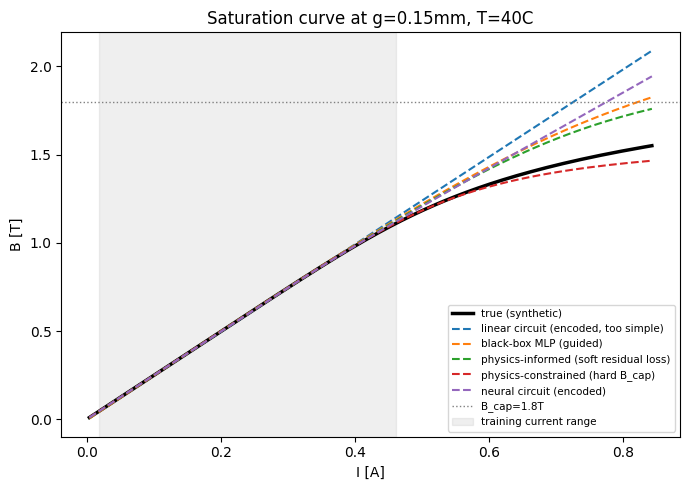

In [4]:
B_range = np.linspace(0.01, 1.55, 200)
g_fixed, T_fixed = 0.15e-3, 40.0
Theta_range = true_theta_from_B(B_range, np.full_like(B_range, g_fixed), np.full_like(B_range, T_fixed))
I_range = Theta_range / N

with torch.no_grad():
    B_lin = solve_B(t(Theta_range), t(np.full_like(B_range, g_fixed)), t(np.full_like(B_range, T_fixed)), linear_model, l_core, n_iter=1).numpy()
    B_mlp_pred = mlp(t(I_range), t(np.full_like(B_range, g_fixed)), t(np.full_like(B_range, T_fixed))).numpy()
    B_informed = informed(t(I_range), t(np.full_like(B_range, g_fixed)), t(np.full_like(B_range, T_fixed))).numpy()
    B_constrained = constrained(t(I_range), t(np.full_like(B_range, g_fixed)), t(np.full_like(B_range, T_fixed))).numpy()
    B_nc = solve_B(t(Theta_range), t(np.full_like(B_range, g_fixed)), t(np.full_like(B_range, T_fixed)), neural_circuit, l_core, n_iter=8).numpy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(I_range, B_range, "k-", linewidth=2.5, label="true (synthetic)")
ax.plot(I_range, B_lin, "--", label="linear circuit (encoded, too simple)")
ax.plot(I_range, B_mlp_pred, "--", label="black-box MLP (guided)")
ax.plot(I_range, B_informed, "--", label="physics-informed (soft residual loss)")
ax.plot(I_range, B_constrained, "--", label="physics-constrained (hard B_cap)")
ax.plot(I_range, B_nc, "--", label="neural circuit (encoded)")
ax.axhline(B_cap, color="gray", linestyle=":", linewidth=1, label=f"B_cap={B_cap}T")
ax.axvspan(I_tr.min(), I_tr.max(), color="gray", alpha=0.12, label="training current range")
ax.set_xlabel("I [A]"); ax.set_ylabel("B [T]"); ax.legend(fontsize=7.5, loc="lower right")
ax.set_title(f"Saturation curve at g={g_fixed*1e3:.2f}mm, T={T_fixed:.0f}C")
plt.tight_layout(); plt.show()


## 10. Evaluation

MSE on $B$ [T], train (interpolation) plus the three extrapolation holdouts.

In [5]:
def predict_all(I, g, T):
    Theta = t(I * N)
    with torch.no_grad():
        B_lin = solve_B(Theta, t(g), t(T), linear_model, l_core, n_iter=1).numpy()
        B_mlp = mlp(t(I), t(g), t(T)).numpy()
        B_inf = informed(t(I), t(g), t(T)).numpy()
        B_con = constrained(t(I), t(g), t(T)).numpy()
        B_nc = solve_B(Theta, t(g), t(T), neural_circuit, l_core, n_iter=8).numpy()
    return B_lin, B_mlp, B_inf, B_con, B_nc

rows = []
print(f"{'set':10s} {'linear':>9s} {'MLP':>9s} {'informed':>9s} {'constr.':>9s} {'neural circ.':>13s}")
for name, I, g, T, B_true in [
    ("train", I_tr, g_tr, T_tr, B_tr),
    ("extrap I", I_te_I, g_te_I, T_te_I, B_te_I),
    ("extrap g", I_te_g, g_te_g, T_te_g, B_te_g),
    ("extrap T", I_te_T, g_te_T, T_te_T, B_te_T),
]:
    B_lin, B_mlp, B_inf, B_con, B_nc = predict_all(I, g, T)
    mse_lin = float(np.mean((B_lin - B_true) ** 2))
    mse_mlp = float(np.mean((B_mlp - B_true) ** 2))
    mse_inf = float(np.mean((B_inf - B_true) ** 2))
    mse_con = float(np.mean((B_con - B_true) ** 2))
    mse_nc = float(np.mean((B_nc - B_true) ** 2))
    rows.append((name, mse_lin, mse_mlp, mse_inf, mse_con, mse_nc))
    print(f"{name:10s} {mse_lin:9.5f} {mse_mlp:9.5f} {mse_inf:9.5f} {mse_con:9.5f} {mse_nc:13.5f}")


set           linear       MLP  informed   constr.  neural circ.
train        0.00003   0.00001   0.00000   0.00000       0.00000
extrap I     0.01251   0.00400   0.00307   0.00031       0.00421
extrap g     0.00001   0.00187   0.00117   0.00060       0.00000
extrap T     0.00029   0.00009   0.00000   0.00001       0.00000


## 11. Discussion

Five models now, and the winner changes by axis *and* by which kind of physics each model actually carries:

| set | linear (encoded) | MLP (guided) | informed | constrained | neural circuit (encoded) |
|---|---|---|---|---|---|
| train | 0.00003 | 0.00001 | 0.00000 | 0.00000 | 0.00000 |
| extrap I (saturation) | 0.01251 | 0.00400 | 0.00307 | **0.00031** | 0.00421 |
| extrap g | 0.00001 | 0.00187 | 0.00117 | 0.00060 | **0.00000** |
| extrap T | 0.00029 | 0.00009 | **0.00000** | 0.00001 | **0.00000** |

- **Extrapolating current (deeper saturation):** the *physics-constrained* model wins outright here — better even than the fully physics-encoded neural circuit. Its hard `B_cap=1.8T` bound is exactly the right prior for this specific failure mode: pushed into current values it never trained on, a completely free MLP (or an under-penalized informed model) can keep extrapolating its output upward without limit, while `PhysicsConstrainedB` is structurally incapable of ever predicting past its cap, regardless of how far out-of-distribution the input is. It doesn't know the *shape* of the saturation curve (unlike the neural circuit, which gets Ampere's law exactly), but knowing the *ceiling* alone already beats a model that has more physics but no such ceiling.
- **Extrapolating air gap:** the neural circuit is again essentially exact, because $R_{\text{gap}}=g/(\mu_0 A)$ is exact geometry baked into its forward pass. Nothing else — not the soft residual, not the hard cap — encodes that specific relationship, so both come in behind it here.
- **Extrapolating temperature:** informed and neural-circuit effectively tie for best, both far ahead of the guided MLP and the constrained model. The physics-informed model's Ampere's-law residual involves $T$ through its own learned $\mu_r(B,T)$, and apparently that soft coupling generalizes across temperature about as well as the exactly-encoded version does here — a genuinely different outcome from Notebook 05's PINN, where the same *kind* of soft residual loss did **not** help extrapolation at all.

**Why does the soft residual help here but not in Notebook 05?** Both are "physics-informed" in the same structural sense (equation as an extra loss term, nothing enforced at inference), but the residuals are different kinds of objects. Notebook 05's residual is a PDE derivative in *time* — satisfying it at collocation points spanning two periods of a 50 Hz signal says nothing about behavior at a completely different oscillation timescale (200 Hz) the residual never touched. This notebook's residual is an *algebraic* constraint over $(I,g,T)$ collocation points drawn from the same box the training data lives in — extrapolating current, gap, or temperature is extrapolating a smooth, low-order relationship past a boundary, not evaluating a wave equation at a frequency an integral never sampled. Soft physics penalties can help extrapolation; whether they do depends on how smoothly the underlying relationship extends past where the penalty was actually evaluated — not on being "physics-informed" in name.

The bigger picture, now spanning three notebooks with basically the same message stated three different ways: **the type of physics constraint matters as much as whether physics is present at all.** Notebook 02's unconstrained additive UDE residual actively hurt out-of-range extrapolation; this notebook's unconstrained-but-well-scaled soft residual (`PhysicsInformedB`) helped on two of three axes and was merely mediocre on the third; a single hard bound with zero equation knowledge (`PhysicsConstrainedB`) won the one axis its bound was actually relevant to; and full structural encoding (`NeuralMuR`, the linear circuit's air-gap term) won wherever the *exact* relationship it encodes was the one being tested. No single pattern dominates every axis — which pattern to reach for depends on what you actually know for certain (a ceiling? an exact sub-relationship? nothing but the governing equation's form?), not on maximizing how much physics gets used.

## 12. Relevance for ATLAS

This is closest to a direct, low-risk upgrade path for ATLAS's assumed linear circuit: same series topology, same always-exact air-gap term, one bounded learned correction for the one genuinely uncertain quantity (core permeability). The extrapolation results above are a concrete argument for why this is worth doing — the linear model's saturation blind spot is exactly the kind of error a brake operating near its magnetic limits would be most sensitive to. The current-extrapolation result adds a second, more general lesson: if ATLAS's core saturation value is known even approximately from a datasheet, a hard cap on predicted flux density is cheap insurance against exactly this failure mode, independent of whichever model architecture ends up used for everything else.

## 13. Next step

`04_graph_cauer_surface_depth.ipynb` — extend Notebook 01's 1D Cauer ladder into a 2D graph (surface × depth) to add lateral eddy-current redistribution and velocity dependence, the central candidate method for ATLAS per `00_overview_methods.ipynb`.